In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanbera19/bengaluru-house-price-dataset")

print("Path to dataset files:", path)

import os
print(os.getcwd())
print(os.listdir())

Path to dataset files: C:\Users\shubh\.cache\kagglehub\datasets\sumanbera19\bengaluru-house-price-dataset\versions\1
c:\Users\shubh\OneDrive\Desktop\Files\05052026
['Bengaluru House Price Prediction Documentation.docx', 'Bengaluruhouseprice.ipynb', 'bengaluru_house_prices.csv', 'bengaluru_model_pipeline.py', 'bengaluru_outlier_removal.py', 'Documentation.txt', '~$ngaluru House Price Prediction Documentation.docx']


In [114]:
import pandas as pd
df = pd.read_csv('bengaluru_house_prices.csv')
df.head(3)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [116]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

Shape: (13320, 9)

Columns: Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


In [117]:
for k in df.columns:
    print (f'{k} :{df[k].value_counts()}')  
    print('****'* 20)

area_type :area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
********************************************************************************
availability :availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
********************************************************************************
location :location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,  

In [118]:
for k in df.columns:
    print (f'{k} :{df[k].unique()}')
    print('****'* 20)

area_type :['Super built-up  Area' 'Plot  Area' 'Built-up  Area' 'Carpet  Area']
********************************************************************************
availability :['19-Dec' 'Ready To Move' '18-May' '18-Feb' '18-Nov' '20-Dec' '17-Oct'
 '21-Dec' '19-Sep' '20-Sep' '18-Mar' '20-Feb' '18-Apr' '20-Aug' '18-Oct'
 '19-Mar' '17-Sep' '18-Dec' '17-Aug' '19-Apr' '18-Jun' '22-Dec' '22-Jan'
 '18-Aug' '19-Jan' '17-Jul' '18-Jul' '21-Jun' '20-May' '19-Aug' '18-Sep'
 '17-May' '17-Jun' '21-May' '18-Jan' '20-Mar' '17-Dec' '16-Mar' '19-Jun'
 '22-Jun' '19-Jul' '21-Feb' 'Immediate Possession' '19-May' '17-Nov'
 '20-Oct' '20-Jun' '19-Feb' '21-Oct' '21-Jan' '17-Mar' '17-Apr' '22-May'
 '19-Oct' '21-Jul' '21-Nov' '21-Mar' '16-Dec' '22-Mar' '20-Jan' '21-Sep'
 '21-Aug' '14-Nov' '19-Nov' '15-Nov' '16-Jul' '15-Jun' '17-Feb' '20-Nov'
 '20-Jul' '16-Sep' '15-Oct' '15-Dec' '16-Oct' '22-Nov' '15-Aug' '17-Jan'
 '16-Nov' '20-Apr' '16-Jan' '14-Jul']
**************************************************************

In [119]:
#Drop columns
df = df.drop(['area_type', 'society', 'balcony', 'availability'], axis=1)
# df.drop(['area_type', 'society', 'balcony', 'availability'], axis=1, inplace=True) inplace = true when we want to make changes in the original dataframe. If inplace = false, then it will return a new dataframe with the changes made and the original dataframe will remain unchanged.

In [120]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [121]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [122]:
df = df.dropna().reset_index(drop=True) #drop all the rows with null values from the dataframe. This is done to ensure that the dataset is clean and does not contain any missing values that could affect the analysis.

In [123]:
df.sample(5)

,location,size,total_sqft,bath,price
10522,Electronic City,2 BHK,1025,2.0,50.0
11395,Electronic City,2 BHK,1060,2.0,55.0
6109,Shettihalli,4 Bedroom,2100,4.0,90.0
8525,Badavala Nagar,3 BHK,1842,3.0,115.0
3626,Sarakki Nagar,3 BHK,2145,4.0,270.0


In [124]:
# df['size'].str.extract(r'(\d+)').astype(float) -- for this index alignment requireed explicitly
df.loc[:, 'bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

In [125]:
print(df[['bhk', 'size']].head(5))

   bhk       size
0    2      2 BHK
1    4  4 Bedroom
2    3      3 BHK
3    3      3 BHK
4    2      2 BHK


In [126]:
df.drop(['size'], axis=1, inplace=True) #drop the size column from the dataframe. This is done because we have already extracted the number of bedrooms from the size column and stored it in a new column called bhk. Therefore, we no longer need the size column in the dataframe.

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

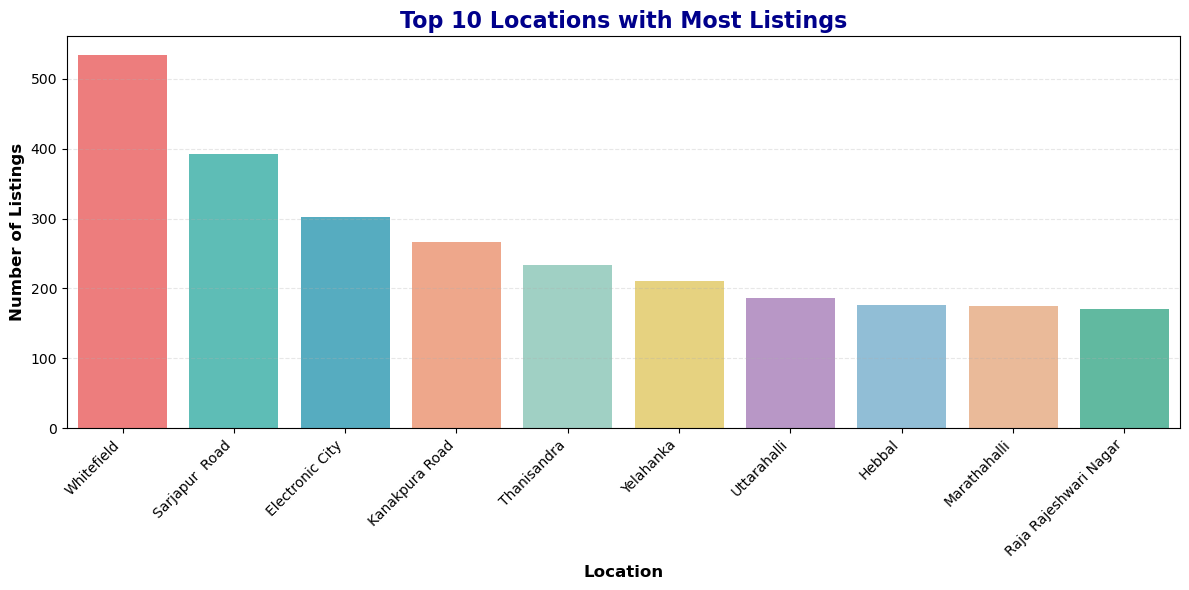

In [128]:
# Top 10 locations with most listings
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=pd.DataFrame({'location': top_locations.index, 'count': top_locations.values}), 
            x='location', y='count', hue='location', palette=colors, legend=False)
plt.title('Top 10 Locations with Most Listings', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Location', fontsize=12, fontweight='bold')
plt.ylabel('Number of Listings', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

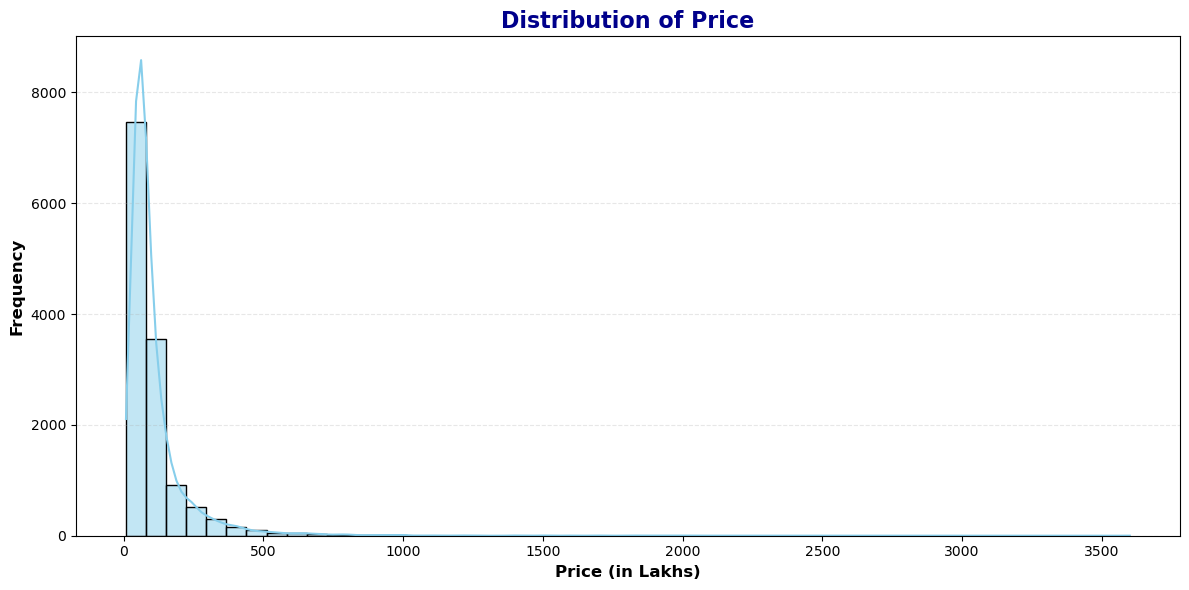

In [129]:
# Distribution of price
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Price (in Lakhs)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

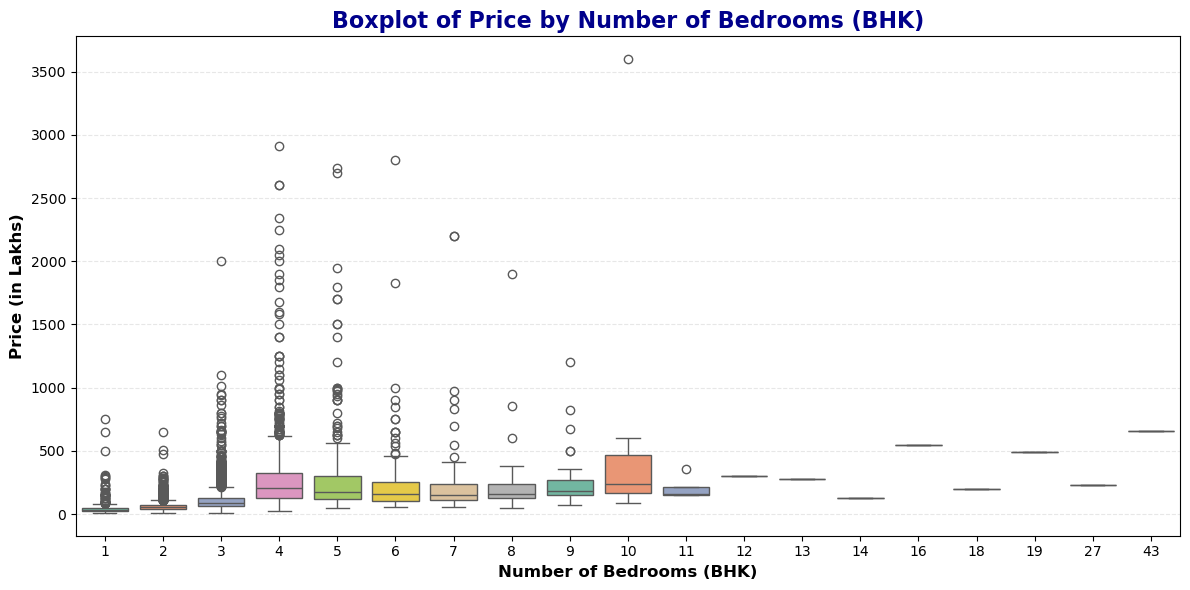

In [130]:
# Boxplot of price by number of bedrooms (bhk)
plt.figure(figsize=(12, 6))
sns.boxplot(x='bhk', y='price', data=df, hue='bhk', palette='Set2', dodge=False, legend=False)
plt.title('Boxplot of Price by Number of Bedrooms (BHK)', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Number of Bedrooms (BHK)', fontsize=12, fontweight='bold')
plt.ylabel('Price (in Lakhs)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [131]:
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056,2.0,39.07,2
1,Chikka Tirupathi,2600,5.0,120.00,4
2,Uttarahalli,1440,2.0,62.00,3
3,Lingadheeranahalli,1521,3.0,95.00,3
4,Kothanur,1200,2.0,51.00,2


In [132]:
df.shape

(13246, 5)

In [133]:
df.total_sqft.sample(20)

650      3385
367      1166
2674     3200
11754    1310
3037     1400
3980     1097
1854     2000
6556     1355
5062      850
5387     1005
6186      929
7897     1128
8262      952
7372     1545
4395     1996
7914     1175
1873     1174
8097     1630
4010     1532
10255    1260
Name: total_sqft, dtype: object

In [140]:
# Add new column: price per sqft pps
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [134]:
import numpy as np

def sqft_convert(x):
    """
    Converts total_sqft values to a single float.
    Handles:
      - Plain numbers:  "1200"      → 1200.0
      - Ranges:         "2100-2850" → 2475.0 (average)
      - Bad values:     "34.46Sq."  → NaN (drop later)
    """
    # Case 1: It's a range like "2100-2850"
    if '-' in str(x):
        parts = str(x).split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan  # If conversion fails, return NaN

    try:
        return float(x)
    except:
        return np.nan  # Handles "Sq. Meter", "Perch", etc.

df['total_sqft'] = df['total_sqft'].apply(sqft_convert)

df = df.dropna(subset=['total_sqft']).reset_index(drop=True)  # Drop rows where total_sqft conversion failed

In [135]:
print("After sqft conversion:", df.shape)

After sqft conversion: (13200, 5)


In [136]:
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [137]:
# Clean Location 
df['location'] = df['location'].apply(lambda x: x.strip() if isinstance(x,str) else x)  # Strip whitespace from location names, only if they are strings

# as there are many locations with very few data points, we will group them into a single category called "other". This will help us to reduce the number of unique locations and make our model more robust.
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

print('Unique locations:', df['location'].nunique())

Unique locations: 241


In [138]:
#Remove rows wher total_sqft is less than 300 sqft as they are not realistic for residential properties.
# This will help us to remove outliers and make our model more robust.
df = df[df['total_sqft'] / df['bhk'] >= 300].reset_index(drop=True)
print("After removing unrealistic sqft:", df.shape)

After removing unrealistic sqft: (12456, 5)


In [141]:
#Removing Location-Wise Price per sqft Outliers
def remove_pps_outliers(df):
    cleaned_df = pd.DataFrame()
    for location, group in df.groupby('location'):
        mean = np.mean(group.price_per_sqft)
        std = np.std(group.price_per_sqft)

        # Keep only rows where price_per_sqft is within one standard deviation of the mean for that location
        filtered = group[(group['price_per_sqft'] > (mean - std)) & 
                         (group['price_per_sqft'] <= (mean + std))]
        
        cleaned_df = pd.concat([cleaned_df, filtered], ignore_index=True)

    return cleaned_df

# Apply the function to clean the dateset
df = remove_pps_outliers(df)

print("After removing price per sqft outliers:", df.shape)

After removing price per sqft outliers: (10242, 6)


In [142]:
# function to remove BHK-based pricing outliers for each location
def remove_bhk_outliers(df):
    indices_to_remove = []

    for location, location_df in df.groupby('location'):
        bhk_price_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_price_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            if bhk - 1 in bhk_price_stats:
                mean = bhk_price_stats[bhk - 1]['mean']
                std = bhk_price_stats[bhk - 1]['std']
                count = bhk_price_stats[bhk - 1]['count']

                # Only consider outliers if there are enough data points for the (bhk-1) category
                if count > 5:
                    outliers = bhk_df[bhk_df.price_per_sqft < (mean - std)]
                    indices_to_remove.extend(outliers.index)
    return df.drop(indices_to_remove, axis='index')    

df = remove_bhk_outliers(df)
print("After removing BHK-based pricing outliers:", df.shape)            

After removing BHK-based pricing outliers: (9483, 6)


In [143]:
#Removing Unrealistic Bathroom Outliers

df =df[df['bath'] < df['bhk'] + 2].reset_index(drop=True)
print("After removing bathroom outliers:", df.shape)

After removing bathroom outliers: (9395, 6)


In [176]:
df.head(5)

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [145]:
df_model = df.drop(['price_per_sqft'], axis=1)
df_model.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [146]:
# Create dummy variables for location (one-hot encoding)
dummies = pd.get_dummies(df_model['location'],dtype=int)

In [147]:
dummies

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9392,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9393,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [148]:
df_model = pd.concat([df_model.drop('location', axis=1), dummies], axis=1)
df_model.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [149]:
print("Final shape of the dataset after preprocessing:", df_model.shape)

Final shape of the dataset after preprocessing: (9395, 245)


In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

 # DATASET OVERVIEW

In [152]:
# X = all feature columns (total_sqft, bhk, bath, location OHE columns...)
# y = target column (price in Lakhs)
X = df_model.drop(columns=["price"])
y = df_model["price"]

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Total rows       : {len(df)}")
print(f"  Total features   : {X.shape[1]}")
print(f"  Target (price)   : min=₹{y.min():.1f}L  max=₹{y.max():.1f}L  mean=₹{y.mean():.1f}L")


  DATASET OVERVIEW
  Total rows       : 9395
  Total features   : 244
  Target (price)   : min=₹10.0L  max=₹2200.0L  mean=₹91.2L


In [154]:
# =============================================================================
#  STEP 1 — Train / Test Split  (80% train | 20% test)
# =============================================================================
#
#  WHY split BEFORE anything else?
#    The test set represents future unseen data.
#    If you scale or encode using the full dataset first, test-set
#    statistics leak into training — scores are artificially inflated.
#
#  WHY random_state=42?
#    Seeds the shuffle so every run produces the same split.
#
#  WHY shuffle=True (default)?
#    Prevents order bias. If rows were sorted by price or location,
#    the first 80% would not represent the full distribution.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% held out for final evaluation
    random_state=42,     # reproducibility
    shuffle=True         # shuffle before splitting (default=True)
)

print("\n" + "=" * 60)
print("  STEP 1 · Train / Test Split")
print("=" * 60)
print(f"  Training rows : {X_train.shape[0]}")
print(f"  Testing rows  : {X_test.shape[0]}")

# Sanity check — make sure no row appears in both sets
assert len(set(X_train.index) & set(X_test.index)) == 0
print("  ✅ No data leakage — train and test indices are disjoint")


  STEP 1 · Train / Test Split
  Training rows : 7516
  Testing rows  : 1879
  ✅ No data leakage — train and test indices are disjoint


In [155]:
# =============================================================================
#  HELPER — Evaluation utility
# =============================================================================

def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te, cv_scores):
    """Fits the pipeline, predicts on test set, and prints a report."""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    test_r2  = r2_score(y_te, y_pred)
    test_mae = mean_absolute_error(y_te, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  5-Fold CV  →  Mean R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
    print(f"  Fold scores : {np.round(cv_scores, 4)}")
    print(f"  Test R²     : {test_r2:.4f}")
    print(f"  Test MAE    : ₹{test_mae:.2f} Lakhs")
    print(f"  Test RMSE   : ₹{test_rmse:.2f} Lakhs")

    return pipeline, y_pred, {
        "model"      : name,
        "cv_mean_r2" : round(cv_scores.mean(), 4),
        "cv_std_r2"  : round(cv_scores.std(), 4),
        "test_r2"    : round(test_r2, 4),
        "test_mae"   : round(test_mae, 2),
        "test_rmse"  : round(test_rmse, 2),
    }

In [156]:

# =============================================================================
#  STEP 2 — MODEL 1 : Linear Regression
# =============================================================================
#
#  HOW IT WORKS:
#    Fits: price = w1*sqft + w2*bhk + w3*bath + w4*location_A + ... + b
#    Minimises: Sum of squared residuals  Σ(y - ŷ)²
#
#  Pipeline:
#    StandardScaler  →  transforms each feature to zero mean, unit variance
#                       (x - mean) / std
#                       Needed because sqft is in thousands but OHE cols are 0/1.
#                       Unscaled features make coefficients incomparable.
#    LinearRegression → fits OLS on the scaled features
#
#  WHY Pipeline instead of separate fit/transform?
#    During cross-validation, Pipeline ensures the scaler is fit ONLY on
#    the training fold — never on the validation fold.
#    Fitting the scaler on all folds first would leak validation statistics.

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()), # Scale features to zero mean and unit variance
    ("model",  LinearRegression())
])

cv_scores_linear = cross_val_score(
    linear_pipeline,
    X_train, y_train,
    cv=5,           # 5 folds
    scoring="r2"    # R² as the scoring metric
)

linear_pipeline, y_pred_linear, linear_results = evaluate(
    "MODEL 1 · Linear Regression",
    linear_pipeline, X_train, y_train, X_test, y_test,
    cv_scores_linear
)

# Inspect top coefficients (after re-fitting on full train set)
lr_model  = linear_pipeline.named_steps["model"]
coeff_df  = pd.Series(lr_model.coef_, index=X_train.columns)
print("\n  Top 5 features driving price UP:")
print(coeff_df.sort_values(ascending=False).head(5).round(2).to_string())
print("\n  Top 5 features driving price DOWN:")
print(coeff_df.sort_values(ascending=True).head(5).round(2).to_string())


  MODEL 1 · Linear Regression
  5-Fold CV  →  Mean R²: 0.8138  |  Std: 0.0412
  Fold scores : [0.8683 0.7529 0.8446 0.7846 0.8185]
  Test R²     : 0.8151
  Test MAE    : ₹18.86 Lakhs
  Test RMSE   : ₹42.52 Lakhs

  Top 5 features driving price UP:
total_sqft         58.58
Cunningham Road    15.90
Rajaji Nagar       13.35
Indira Nagar        7.77
Malleshwaram        7.14

  Top 5 features driving price DOWN:
Raja Rajeshwari Nagar      -3.31
Electronic City Phase II   -3.02
bhk                        -2.76
Chikka Tirupathi           -2.37
Uttarahalli                -2.36


In [157]:
# =============================================================================
#  STEP 3 — MODEL 2 : Lasso Regression  (L1 Regularisation)
# =============================================================================
#
#  HOW IT WORKS:
#    Normal OLS loss  : Σ(y - ŷ)²
#    Lasso loss       : Σ(y - ŷ)²  +  alpha × Σ|wᵢ|
#                                      └──────────────┘
#                                       L1 penalty — pushes weak
#                                       weights to EXACTLY zero
#
#  WHY Lasso for this dataset?
#    After OHE, we have ~240+ location columns. Most locations
#    have little predictive power. Lasso automatically zeroes
#    them out — acting as built-in feature selection.
#
#  WHY tune alpha with GridSearchCV?
#    alpha=0    → identical to plain Linear Regression (no penalty)
#    alpha=∞    → all weights zeroed (predicts the mean)
#    We search 20 values on a log scale to find the sweet spot.
#
#  WHY log scale for alpha?
#    Alpha's effect is multiplicative. The difference between
#    0.001 and 0.01 matters as much as between 1 and 10.
#    Linear spacing would cluster candidates near one end.

lasso_base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Lasso(max_iter=10000))   # max_iter: convergence budget
])

param_grid_lasso = {
    # "model__alpha" targets the alpha param inside the pipeline's "model" step
    "model__alpha": np.logspace(-3, 2, 20)   # 0.001 → 100 on log scale
}

grid_lasso = GridSearchCV(
    lasso_base_pipeline,
    param_grid_lasso,
    cv=5,
    scoring="r2",
    n_jobs=-1    # use all CPU cores
)
grid_lasso.fit(X_train, y_train)

best_alpha = grid_lasso.best_params_["model__alpha"]
print(f"\n  [Lasso] Best alpha   : {best_alpha:.6f}")
print(f"  [Lasso] Best CV R²   : {grid_lasso.best_score_:.4f}")

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Lasso(alpha=best_alpha, max_iter=10000))
])

cv_scores_lasso = cross_val_score(
    lasso_pipeline,
    X_train, y_train,
    cv=5,
    scoring="r2"
)

lasso_pipeline, y_pred_lasso, lasso_results = evaluate(
    "MODEL 2 · Lasso Regression",
    lasso_pipeline, X_train, y_train, X_test, y_test,
    cv_scores_lasso
)

# Show sparsity — how many features did Lasso zero out?
lasso_coefs   = lasso_pipeline.named_steps["model"].coef_
n_nonzero     = np.sum(lasso_coefs != 0)
n_total       = len(lasso_coefs)
print(f"\n  Features selected  : {n_nonzero} / {n_total}")
print(f"  Features zeroed out: {n_total - n_nonzero}  (auto feature selection!)")



  [Lasso] Best alpha   : 0.069519
  [Lasso] Best CV R²   : 0.8139

  MODEL 2 · Lasso Regression
  5-Fold CV  →  Mean R²: 0.8139  |  Std: 0.0409
  Fold scores : [0.8683 0.754  0.8444 0.7842 0.8186]
  Test R²     : 0.8151
  Test MAE    : ₹18.86 Lakhs
  Test RMSE   : ₹42.52 Lakhs

  Features selected  : 228 / 244
  Features zeroed out: 16  (auto feature selection!)


In [171]:
 
from sklearn.ensemble import RandomForestRegressor
 
# XGBoost is a separate package, not part of scikit-learn.
#   pip install xgboost
from xgboost import XGBRegressor

In [158]:
# =============================================================================
#  STEP 4 — MODEL 3 : Decision Tree Regressor
# =============================================================================
#
#  HOW IT WORKS:
#    Learns binary if-then rules:
#      "IF total_sqft > 1500 AND location_Whitefield = 1 → price ≈ ₹85L"
#    At each node, picks the feature + threshold that minimises child MSE.
#    Leaf prediction = mean(y) of all training rows reaching that leaf.
#
#  WHY no StandardScaler?
#    Trees split on thresholds, not magnitudes or distances.
#    Feature scale is completely irrelevant for tree-based models.
#
#  KEY RISK — Overfitting:
#    With max_depth=None, the tree can grow until every leaf has 1 row.
#    That gives R²=1.0 on training data but terrible on test data.
#    We tune max_depth and min_samples_leaf via GridSearchCV to prevent this.
#
#  WHY tune min_samples_leaf?
#    Forces every leaf to represent at least N training samples.
#    Higher value → smoother predictions → less overfitting.

dt_base_pipeline = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
    # No scaler — trees are scale-invariant
])

param_grid_dt = {
    "model__max_depth"        : [3, 5, 7, 10, 15, None],
    "model__min_samples_leaf" : [1, 5, 10, 20],
}

grid_dt = GridSearchCV(
    dt_base_pipeline,
    param_grid_dt,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

best_depth = grid_dt.best_params_["model__max_depth"]
best_leaf  = grid_dt.best_params_["model__min_samples_leaf"]
print(f"\n  [Decision Tree] Best max_depth        : {best_depth}")
print(f"  [Decision Tree] Best min_samples_leaf : {best_leaf}")
print(f"  [Decision Tree] Best CV R²            : {grid_dt.best_score_:.4f}")

dt_pipeline = Pipeline([
    ("model", DecisionTreeRegressor(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        random_state=42
    ))
])

cv_scores_dt = cross_val_score(
    dt_pipeline,
    X_train, y_train,
    cv=5,
    scoring="r2"
)

dt_pipeline, y_pred_dt, dt_results = evaluate(
    "MODEL 3 · Decision Tree Regressor",
    dt_pipeline, X_train, y_train, X_test, y_test,
    cv_scores_dt
)

# Feature importances — unique to tree models
dt_model    = dt_pipeline.named_steps["model"]
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
print("\n  Top 10 Most Important Features (Decision Tree):")
print(importances.sort_values(ascending=False).head(10).round(4).to_string())

# Print top 3 levels of the decision tree as human-readable rules
rules = export_text(dt_model, feature_names=list(X_train.columns), max_depth=3)
print("\n  Decision Rules (top 3 levels):")
print(rules)


  [Decision Tree] Best max_depth        : 15
  [Decision Tree] Best min_samples_leaf : 1
  [Decision Tree] Best CV R²            : 0.7250

  MODEL 3 · Decision Tree Regressor
  5-Fold CV  →  Mean R²: 0.7250  |  Std: 0.0311
  Fold scores : [0.6915 0.6945 0.7561 0.7161 0.7666]
  Test R²     : 0.7029
  Test MAE    : ₹20.29 Lakhs
  Test RMSE   : ₹53.91 Lakhs

  Top 10 Most Important Features (Decision Tree):
total_sqft         0.8111
Cunningham Road    0.0358
Rajaji Nagar       0.0271
bhk                0.0268
Indira Nagar       0.0137
other              0.0117
bath               0.0112
Malleshwaram       0.0087
Giri Nagar         0.0086
HAL 2nd Stage      0.0062

  Decision Rules (top 3 levels):
|--- total_sqft <= 2144.80
|   |--- total_sqft <= 1465.50
|   |   |--- total_sqft <= 1196.50
|   |   |   |--- total_sqft <= 894.50
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- total_sqft >  894.50
|   |   |   |   |--- truncated branch of depth 12
|   |   |--- total_sqft >  1

In [172]:
    
# =============================================================================
#  STEP 5 — MODEL 4 : Random Forest Regressor
# =============================================================================
#
#  HOW IT WORKS:
#    Builds many independent Decision Trees (n_estimators=200), each on:
#      - a random BOOTSTRAP sample of rows (sampling with replacement)
#      - a random SUBSET of the 244 columns at every split
#    Final prediction = average of all 200 trees' predictions.
#
#  WHY does this fix the single Decision Tree's weakness?
#    Your Decision Tree had the highest CV std deviation of the 3 models —
#    meaning it's unstable, sensitive to exactly which rows it trains on.
#    Averaging 200 de-correlated trees cancels out each tree's individual
#    errors. This is "bagging" (Bootstrap AGGregatING) — it reduces
#    VARIANCE without increasing bias much.
#
#  WHY max_features="sqrt" matters here specifically:
#    You have 244 columns (mostly sparse location dummy columns).
#    Without restricting features per split, every tree would keep
#    picking total_sqft or bhk first — making all 200 trees nearly
#    identical, which defeats the purpose of averaging.
#    max_features="sqrt" → each split only considers ~√244 ≈ 15 random
#    columns, forcing trees to diversify and occasionally split on
#    location dummies that a single tree might ignore.
#
#  NO SCALER NEEDED — same reasoning as your Decision Tree: trees split
#  on thresholds, not magnitudes, so StandardScaler is irrelevant here.
 
rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=200,      # number of trees
        max_depth=12,          # deeper than a single DT is OK — averaging controls overfitting
        min_samples_leaf=2,
        max_features="sqrt",   # ~15 random features considered per split (out of 244)
        random_state=42,
        n_jobs=-1                # trees are independent — parallelize freely
    ))
])
 
cv_scores_rf = cross_val_score(
    rf_pipeline,
    X_train, y_train,
    cv=5,
    scoring="r2"
)
 
rf_pipeline, y_pred_rf, rf_results = evaluate(
    "MODEL 4 · Random Forest Regressor",
    rf_pipeline, X_train, y_train, X_test, y_test,
    cv_scores_rf
)
 
# Feature importance — same interface as Decision Tree, but averaged
# across all 200 trees, making it a more stable importance ranking.
rf_model       = rf_pipeline.named_steps["model"]
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print("\n  Top 10 Most Important Features (Random Forest):")
print(rf_importances.sort_values(ascending=False).head(10).round(4).to_string())


  MODEL 4 · Random Forest Regressor
  5-Fold CV  →  Mean R²: 0.6417  |  Std: 0.0581
  Fold scores : [0.5348 0.6942 0.6317 0.6577 0.6903]
  Test R²     : 0.5327
  Test MAE    : ₹25.82 Lakhs
  Test RMSE   : ₹67.61 Lakhs

  Top 10 Most Important Features (Random Forest):
total_sqft         0.3902
bath               0.2413
bhk                0.1827
Cunningham Road    0.0542
Rajaji Nagar       0.0372
Giri Nagar         0.0109
Indira Nagar       0.0109
Malleshwaram       0.0080
Iblur Village      0.0054
Frazer Town        0.0053


In [173]:

# =============================================================================
#  STEP 6 — MODEL 5 : XGBoost Regressor
# =============================================================================
#
#  HOW IT WORKS (Gradient Boosting — fundamentally different from RF):
#    Trees are built SEQUENTIALLY, not independently.
#      Tree 1 → makes an initial rough prediction
#      Tree 2 → trained to correct Tree 1's leftover errors (residuals)
#      Tree 3 → trained to correct what's still wrong after Tree 1 + Tree 2
#      ... repeated for n_estimators=300 rounds
#    Final prediction = weighted SUM of all trees (weighted by learning_rate),
#    not an average like Random Forest.
#
#  WHY shallow trees (max_depth=4) here, vs depth=12 for Random Forest?
#    Each RF tree must independently capture the whole pattern, so it
#    needs depth. Each XGBoost tree only needs to learn a SMALL
#    correction to the previous trees' mistakes — a shallow tree is
#    enough, and keeping it shallow prevents any single round from
#    overfitting to noise in the residuals.
#
#  WHY learning_rate=0.05 (small)?
#    Each tree's contribution is scaled down by this factor before being
#    added to the running prediction. Small learning_rate + more trees
#    (n_estimators=300) gives smoother, more generalizable corrections
#    than a few large, aggressive correction steps.
#
#  WHY subsample=0.8 and colsample_bytree=0.8?
#    Each tree sees only 80% of rows and 80% of the 244 columns,
#    selected randomly. This injects controlled randomness — similar
#    in spirit to Random Forest's bootstrapping — which reduces
#    overfitting in the boosting process.
 
xgb_pipeline = Pipeline([
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])
 
cv_scores_xgb = cross_val_score(
    xgb_pipeline,
    X_train, y_train,
    cv=5,
    scoring="r2"
)
 
xgb_pipeline, y_pred_xgb, xgb_results = evaluate(
    "MODEL 5 · XGBoost Regressor",
    xgb_pipeline, X_train, y_train, X_test, y_test,
    cv_scores_xgb
)
 
xgb_model       = xgb_pipeline.named_steps["model"]
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print("\n  Top 10 Most Important Features (XGBoost):")
print(xgb_importances.sort_values(ascending=False).head(10).round(4).to_string())
 
 
# =============================================================================
#  STEP 7 — Compare All 5 Models   (REPLACES your old STEP 5)
# =============================================================================
 
summary = pd.DataFrame([
    linear_results, lasso_results, dt_results, rf_results, xgb_results
])
summary = summary.set_index("model")
 
print("\n" + "=" * 60)
print("  FINAL MODEL COMPARISON — ALL 5 MODELS")
print("=" * 60)
print(summary.to_string())
print("=" * 60)
 
best_model = summary["test_r2"].idxmax()
print(f"\n  🏆 Best Model : {best_model}")
print(f"     Test R²   : {summary.loc[best_model, 'test_r2']}")
print(f"     Test MAE  : ₹{summary.loc[best_model, 'test_mae']} Lakhs")
 
 


  MODEL 5 · XGBoost Regressor
  5-Fold CV  →  Mean R²: 0.7758  |  Std: 0.0684
  Fold scores : [0.7036 0.6903 0.8601 0.7889 0.8358]
  Test R²     : 0.6362
  Test MAE    : ₹19.59 Lakhs
  Test RMSE   : ₹59.65 Lakhs

  Top 10 Most Important Features (XGBoost):
total_sqft         0.1255
Cunningham Road    0.1062
Rajaji Nagar       0.0568
bath               0.0461
other              0.0376
Indira Nagar       0.0375
Malleshwaram       0.0336
Giri Nagar         0.0306
Marathahalli       0.0264
HAL 2nd Stage      0.0252

  FINAL MODEL COMPARISON — ALL 5 MODELS
                                   cv_mean_r2  cv_std_r2  test_r2  test_mae  test_rmse
model                                                                                 
MODEL 1 · Linear Regression            0.8138     0.0412   0.8151     18.86      42.52
MODEL 2 · Lasso Regression             0.8139     0.0409   0.8151     18.86      42.52
MODEL 3 · Decision Tree Regressor      0.7250     0.0311   0.7029     20.29      53.91
MODEL 

In [159]:

# =============================================================================
#  STEP 5 — Compare All Models
# =============================================================================

summary = pd.DataFrame([linear_results, lasso_results, dt_results])
summary = summary.set_index("model")

print("\n" + "=" * 60)
print("  FINAL MODEL COMPARISON")
print("=" * 60)
print(summary.to_string())
print("=" * 60)

best_model = summary["test_r2"].idxmax()
print(f"\n  🏆 Best Model : {best_model}")
print(f"     Test R²   : {summary.loc[best_model, 'test_r2']}")
print(f"     Test MAE  : ₹{summary.loc[best_model, 'test_mae']} Lakhs")


  FINAL MODEL COMPARISON
                                   cv_mean_r2  cv_std_r2  test_r2  test_mae  test_rmse
model                                                                                 
MODEL 1 · Linear Regression            0.8138     0.0412   0.8151     18.86      42.52
MODEL 2 · Lasso Regression             0.8139     0.0409   0.8151     18.86      42.52
MODEL 3 · Decision Tree Regressor      0.7250     0.0311   0.7029     20.29      53.91

  🏆 Best Model : MODEL 1 · Linear Regression
     Test R²   : 0.8151
     Test MAE  : ₹18.86 Lakhs


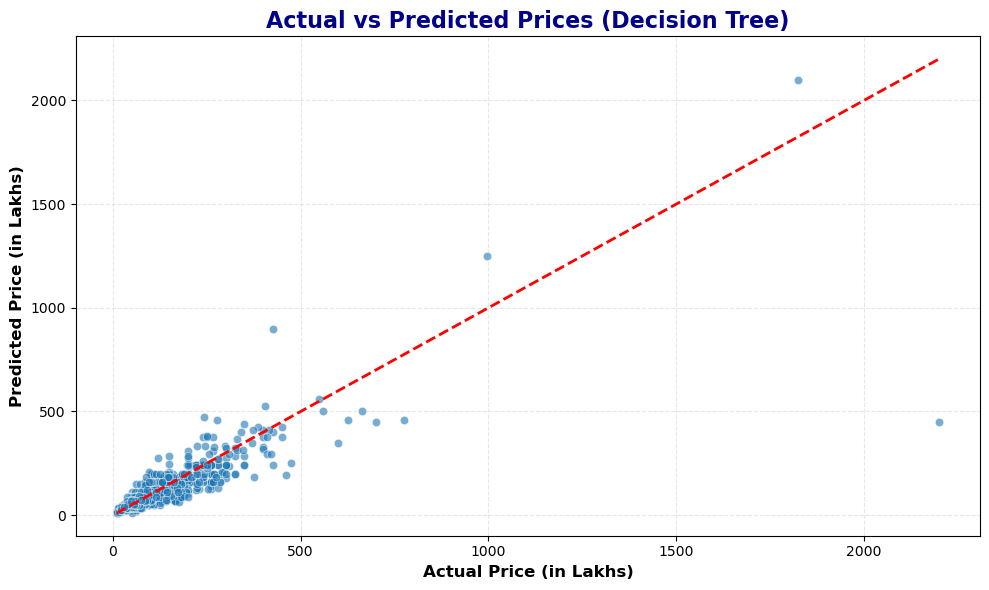

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices (Decision Tree)', fontsize=16, fontweight='bold', color='darkblue')   
plt.xlabel('Actual Price (in Lakhs)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price (in Lakhs)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

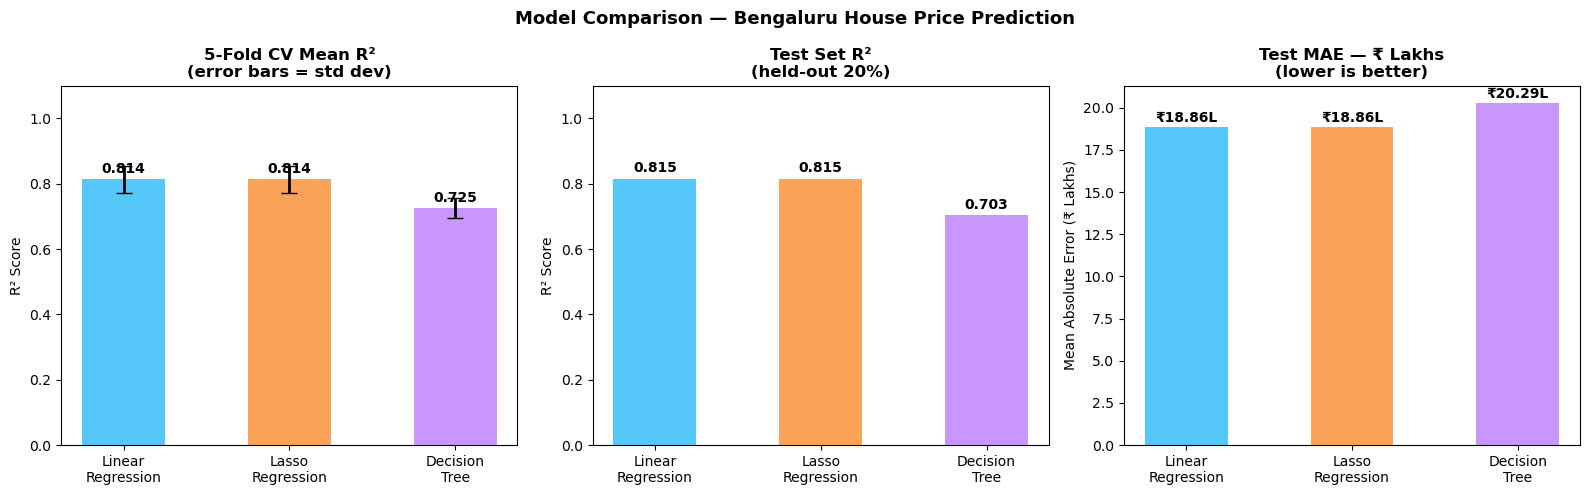


  Chart saved → model_comparison.png


In [160]:

# =============================================================================
#  STEP 6 — Visualise Results
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Bengaluru House Price Prediction", fontsize=13, fontweight="bold")

model_names = ["Linear\nRegression", "Lasso\nRegression", "Decision\nTree"]
colors      = ["#38BDF8", "#FB923C", "#C084FC"]
cv_means    = [cv_scores_linear.mean(), cv_scores_lasso.mean(), cv_scores_dt.mean()]
cv_stds     = [cv_scores_linear.std(),  cv_scores_lasso.std(),  cv_scores_dt.std()]
test_r2s    = [linear_results["test_r2"], lasso_results["test_r2"], dt_results["test_r2"]]
test_maes   = [linear_results["test_mae"], lasso_results["test_mae"], dt_results["test_mae"]]

# --- Plot 1: CV Mean R² with error bars ------------------------------------
bars = axes[0].bar(model_names, cv_means, color=colors, alpha=0.85, width=0.5)
axes[0].errorbar(model_names, cv_means, yerr=cv_stds,
                 fmt="none", color="black", capsize=6, linewidth=2)
axes[0].set_title("5-Fold CV Mean R²\n(error bars = std dev)", fontweight="bold")
axes[0].set_ylabel("R² Score")
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars, cv_means):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

# --- Plot 2: Test R² -------------------------------------------------------
bars2 = axes[1].bar(model_names, test_r2s, color=colors, alpha=0.85, width=0.5)
axes[1].set_title("Test Set R²\n(held-out 20%)", fontweight="bold")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars2, test_r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

# --- Plot 3: Test MAE (lower = better) ------------------------------------
bars3 = axes[2].bar(model_names, test_maes, color=colors, alpha=0.85, width=0.5)
axes[2].set_title("Test MAE — ₹ Lakhs\n(lower is better)", fontweight="bold")
axes[2].set_ylabel("Mean Absolute Error (₹ Lakhs)")
for bar, val in zip(bars3, test_maes):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"₹{val}L", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved → model_comparison.png")


In [169]:
X.shape

(9395, 244)

In [165]:
# =============================================================================
# STEP 6 — Select Best Pipeline & Export Artifacts (No Full Data Retraining)
# =============================================================================
import pickle
#
# AS REQUESTED:
#   We skip retraining on 100% of the data. The pipeline selected below 
#   remains the version trained strictly on X_train during the evaluation phase.
#
# EXPORT DESIGN:
#   We bundle the trained pipeline, the required feature order list, and the 
#   unique locations dictionary into a single dictionary artifact. This guarantees 
#   that app.py has everything it needs to display dropdowns and generate 
#   predictions seamlessly.

# 1. Map the string name back to the actual evaluated pipeline object
pipeline_mapping = {
    "MODEL 1 · Linear Regression": linear_pipeline,
    "MODEL 2 · Lasso Regression": lasso_pipeline,
    "MODEL 3 · Decision Tree Regressor": dt_pipeline
}

selected_pipeline = pipeline_mapping[best_model]

# 2. Extract the clean, unique list of locations directly from the input features
# Defensive: X may have raw 'location', or one-hot columns like 'location_<name>'.
try:
    unique_locations = sorted(X['location'].unique().tolist())
except Exception:
    loc_cols = [c for c in X.columns if str(c).startswith('location_')]
    if loc_cols:
        unique_locations = sorted([c.replace('location_', '') for c in loc_cols])
    else:
        # Fallback to original dataframe if available
        unique_locations = sorted(df['location'].unique().tolist())

# 3. Consolidate all model details, properties, and deployment variables
artifact = {
    "pipeline": selected_pipeline,
    "locations": unique_locations,
    "model_name": best_model,
    "test_r2": float(summary.loc[best_model, "test_r2"]),
    "test_mae": float(summary.loc[best_model, "test_mae"]),
    "test_rmse": float(summary.loc[best_model, "test_rmse"]),
    "feature_columns": list(X.columns)  # Enforces structural order in production
}

# 4. Write binary file to local disk
with open("bengaluru_price_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("\n" + "=" * 60)
# Dynamic space padding calculation to prevent string format corruption
print(f"  ✅ DEPLOYMENT ARTIFACT EXPORTED SUCCESSFUL")
print("=" * 60)
print(f"  Filename   : bengaluru_price_model.pkl")
print(f"  Model Type : {best_model}")
print(f"  Locations  : {len(unique_locations)} unique areas loaded to dropdown.")
print(f"  Metrics    : R² = {artifact['test_r2']:.4f} | MAE = ₹{artifact['test_mae']:.2f} Lakhs")
print("=" * 60)
print("\n  Execution finalized. You are ready to build app.py using this pkl file!")


  ✅ DEPLOYMENT ARTIFACT EXPORTED SUCCESSFUL
  Filename   : bengaluru_price_model.pkl
  Model Type : MODEL 1 · Linear Regression
  Locations  : 241 unique areas loaded to dropdown.
  Metrics    : R² = 0.8151 | MAE = ₹18.86 Lakhs

  Execution finalized. You are ready to build app.py using this pkl file!
